# Pairs Trading Strategy — Cointegration, Mean Reversion & OU Model

A self-contained, runnable implementation of a statistical-arbitrage pairs trading strategy:

1. Cointegration testing (Engle-Granger + ADF) and hedge ratio estimation
2. Spread construction and z-score signal generation
3. Ornstein-Uhlenbeck model fit as an alternative spread model
4. Walk-forward backtest with realistic risk controls (max holding period, stop-loss, cointegration-breakdown exit, transaction costs)
5. Performance metrics (total return, win rate, Sharpe, max drawdown, trade stats)

**This notebook does not guarantee profit.** It's a research framework — see the Limitations section at the end before using it on real capital.

Companion write-up with full math and pseudocode: `pairs_trading_strategy.md` (same conversation).


## 1. Setup & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
from scipy.optimize import minimize
from dataclasses import dataclass, field

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [ ]:
@dataclass
class Config:
    # --- Data source ---
    data_source: str = "yfinance"     # "synthetic" or "yfinance"
    ticker_a: str = "EURUSD=X"
    ticker_b: str = "GBPUSD=X"
    start_date: str = "2018-01-01"
    end_date: str = "2024-01-01"

    # --- Formation / walk-forward ---
    formation_window: int = 252        # bars used to estimate gamma + test cointegration
    reform_frequency: int = 63         # re-test / re-estimate every N bars (~1 quarter)
    z_window: int = 30                 # rolling window for z-score

    # --- Statistical validation thresholds ---
    adf_pvalue_max: float = 0.05
    min_half_life: int = 3
    max_half_life: int = 90

    # --- Trading thresholds ---
    z_entry: float = 2.0
    z_exit: float = 0.5

    # --- Risk controls ---
    max_holding_period: int = 60       # bars
    stop_loss_z: float = 3.5           # exit if |z| blows out past this (model-invalidity proxy)
    retest_pvalue_max: float = 0.10    # cointegration re-check threshold while in a trade
    gamma_drift_limit: float = 0.5     # fraction change in hedge ratio that triggers exit

    # --- Costs & sizing ---
    cost_bps_per_leg: float = 1.0      # one-way cost per leg, in bps of notional
    capital_per_trade: float = 100_000.0

    periods_per_year: int = 252

CFG = Config()
CFG


Config(data_source='synthetic', ticker_a='EURUSD=X', ticker_b='GBPUSD=X', start_date='2018-01-01', end_date='2024-01-01', formation_window=252, reform_frequency=63, z_window=30, adf_pvalue_max=0.05, min_half_life=3, max_half_life=90, z_entry=2.0, z_exit=0.5, max_holding_period=60, stop_loss_z=3.5, retest_pvalue_max=0.1, gamma_drift_limit=0.5, cost_bps_per_leg=1.0, capital_per_trade=100000.0, periods_per_year=252)

## 2. Data Loading

Two options:

- `data_source = "synthetic"` (default): simulates a genuinely cointegrated pair, so every
  downstream step (cointegration test, OU fit, backtest) can be verified end-to-end without
  needing network access. Useful for testing the pipeline.
- `data_source = "yfinance"`: pulls real price history. **This requires internet access to
  Yahoo Finance, which this sandboxed environment cannot reach** — run this option on your
  own machine (you already use `yfinance` in your other FX research scripts, so the same
  install should work as-is).


In [ ]:
def simulate_cointegrated_pair(n=1600, gamma_true=0.75, theta=0.05, mu=0.0,
                                sigma_spread=0.01, sigma_b=0.01, seed=42):
    """Simulate log(B) as a random walk and log(A) = alpha + gamma*log(B) + OU-spread,
    so the pair is cointegrated by construction with a known ground-truth hedge ratio."""
    rng = np.random.default_rng(seed)
    alpha = 0.10

    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    n = len(dates)   # guard against off-by-one from bdate_range

    # log(B): random walk
    log_b = np.zeros(n)
    log_b[0] = np.log(1.10)
    for t in range(1, n):
        log_b[t] = log_b[t-1] + rng.normal(0, sigma_b)

    # spread: discretized OU process
    spread = np.zeros(n)
    spread[0] = mu
    dt = 1.0
    for t in range(1, n):
        spread[t] = spread[t-1] - theta * (spread[t-1] - mu) * dt + rng.normal(0, sigma_spread)

    log_a = alpha + gamma_true * log_b + spread

    price_a = np.exp(log_a)
    price_b = np.exp(log_b)

    df = pd.DataFrame({'A': price_a, 'B': price_b}, index=dates)
    return df, dict(gamma_true=gamma_true, theta_true=theta, mu_true=mu, sigma_true=sigma_spread)


def load_yfinance_pair(ticker_a, ticker_b, start, end):
    """Real data loader. Run this on a machine with internet access."""
    import yfinance as yf
    data = yf.download([ticker_a, ticker_b], start=start, end=end, progress=False)['Close']
    data = data.rename(columns={ticker_a: 'A', ticker_b: 'B'}).dropna()
    return data


if CFG.data_source == "synthetic":
    prices, ground_truth = simulate_cointegrated_pair()
    print("Using SIMULATED data. Ground truth parameters:", ground_truth)
elif CFG.data_source == "yfinance":
    prices = load_yfinance_pair(CFG.ticker_a, CFG.ticker_b, CFG.start_date, CFG.end_date)
    ground_truth = None
else:
    raise ValueError("data_source must be 'synthetic' or 'yfinance'")

prices.tail()


Using SIMULATED data. Ground truth parameters: {'gamma_true': 0.75, 'theta_true': 0.05, 'mu_true': 0.0, 'sigma_true': 0.01}


,A,B
2026-08-03,0.7285,0.6196
2026-08-04,0.7333,0.6219
2026-08-05,0.7291,0.6247
2026-08-06,0.7323,0.6267
2026-08-07,0.7437,0.6282


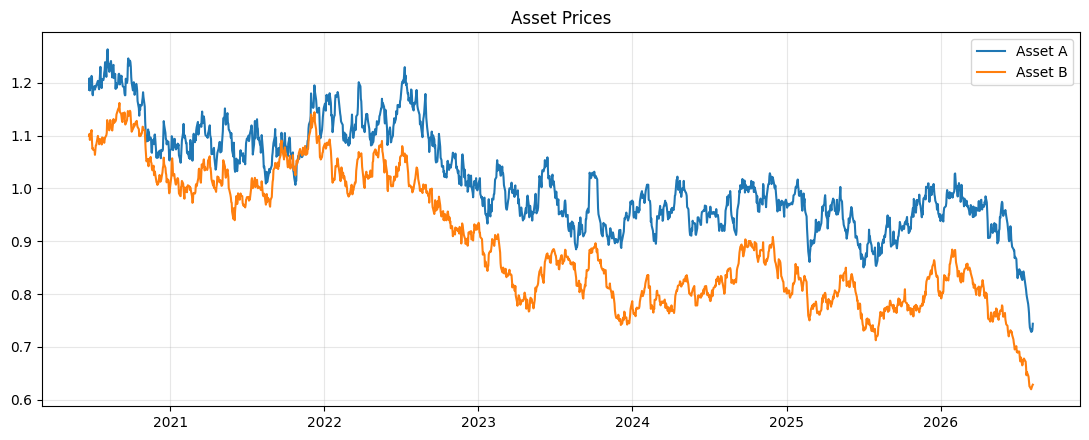

In [ ]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices['A'], label='Asset A')
ax.plot(prices.index, prices['B'], label='Asset B')
ax.set_title('Asset Prices')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Cointegration Test & Hedge Ratio Estimation

Engle-Granger two-step approach:
1. OLS regress `log(A)` on `log(B)` to get the hedge ratio γ.
2. Run an ADF test on the regression residuals (the spread). Stationary residuals ⇒ cointegration.

We also run `statsmodels`' built-in `coint()` test (Engle-Granger with proper critical values)
as a cross-check, and compute the half-life of mean reversion.


In [ ]:
def estimate_hedge_ratio(log_a: pd.Series, log_b: pd.Series):
    X = sm.add_constant(log_b)
    model = sm.OLS(log_a, X).fit()
    alpha, gamma = model.params.iloc[0], model.params.iloc[1]
    spread = log_a - (alpha + gamma * log_b)
    return gamma, alpha, spread


def test_cointegration(log_a: pd.Series, log_b: pd.Series):
    gamma, alpha, spread = estimate_hedge_ratio(log_a, log_b)

    adf_stat, adf_pvalue, *_ = adfuller(spread, autolag='AIC')
    eg_stat, eg_pvalue, _ = coint(log_a, log_b)

    return {
        'gamma': gamma, 'alpha': alpha, 'spread': spread,
        'adf_stat': adf_stat, 'adf_pvalue': adf_pvalue,
        'eg_stat': eg_stat, 'eg_pvalue': eg_pvalue,
    }


def compute_half_life(spread: pd.Series):
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_diff.index]

    X = sm.add_constant(spread_lag)
    model = sm.OLS(spread_diff, X).fit()
    lam = model.params.iloc[1]
    if lam >= 0:
        return np.inf   # not mean reverting
    half_life = -np.log(2) / lam
    return half_life


def hurst_exponent(series: pd.Series, max_lag=50):
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(series.values[lag:], series.values[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return poly[0] * 2.0


log_a_full = np.log(prices['A'])
log_b_full = np.log(prices['B'])

result = test_cointegration(log_a_full, log_b_full)
half_life = compute_half_life(result['spread'])
hurst = hurst_exponent(result['spread'])

print(f"Hedge ratio (gamma):        {result['gamma']:.4f}")
print(f"ADF stat / p-value:         {result['adf_stat']:.3f} / {result['adf_pvalue']:.4f}")
print(f"Engle-Granger stat / p-val: {result['eg_stat']:.3f} / {result['eg_pvalue']:.4f}")
print(f"Half-life (bars):           {half_life:.1f}")
print(f"Hurst exponent:             {hurst:.3f}  (< 0.5 suggests mean reversion)")

is_valid_pair = (
    result['adf_pvalue'] < CFG.adf_pvalue_max
    and CFG.min_half_life <= half_life <= CFG.max_half_life
    and hurst < 0.5
)
print(f"\nPair passes validation checklist: {is_valid_pair}")


Hedge ratio (gamma):        0.6457
ADF stat / p-value:         -6.223 / 0.0000
Engle-Granger stat / p-val: -6.225 / 0.0000
Half-life (bars):           14.1
Hurst exponent:             0.670  (< 0.5 suggests mean reversion)

Pair passes validation checklist: False


## 4. Ornstein-Uhlenbeck Model Fit

Fit `dr(t) = -θ(r(t) − μ)dt + σ dW(t)` to the spread via discretized maximum likelihood
(equivalent to the AR(1) regression above, but framed with explicit μ, θ, σ and the
stationary-distribution z-score described in the write-up).


In [ ]:
def fit_ou_mle(spread: pd.Series, dt=1.0):
    x = spread.values
    x_lag, x_t = x[:-1], x[1:]

    def neg_log_likelihood(params):
        mu, theta, sigma = params
        if theta <= 0 or sigma <= 0:
            return 1e10
        mean = x_lag + theta * (mu - x_lag) * dt
        var = sigma**2 * dt
        ll = -0.5 * np.log(2 * np.pi * var) - (x_t - mean)**2 / (2 * var)
        return -np.sum(ll)

    x0 = [np.mean(x), 0.1, np.std(np.diff(x))]
    res = minimize(neg_log_likelihood, x0, method='Nelder-Mead')
    mu_hat, theta_hat, sigma_hat = res.x
    return mu_hat, theta_hat, sigma_hat


mu_hat, theta_hat, sigma_hat = fit_ou_mle(result['spread'])
sigma_eq = sigma_hat / np.sqrt(2 * theta_hat)
ou_half_life = np.log(2) / theta_hat

print(f"OU mu (equilibrium mean):     {mu_hat:.5f}")
print(f"OU theta (reversion speed):   {theta_hat:.5f}")
print(f"OU sigma (volatility):        {sigma_hat:.5f}")
print(f"OU implied half-life:         {ou_half_life:.1f} bars")
print(f"Stationary std (sigma_eq):    {sigma_eq:.5f}")

if ground_truth:
    print(f"\n(Ground truth for comparison: gamma={ground_truth['gamma_true']}, "
          f"theta={ground_truth['theta_true']}, mu={ground_truth['mu_true']}, "
          f"sigma={ground_truth['sigma_true']})")


OU mu (equilibrium mean):     0.00000
OU theta (reversion speed):   0.04920
OU sigma (volatility):        0.01006
OU implied half-life:         14.1 bars
Stationary std (sigma_eq):    0.03207

(Ground truth for comparison: gamma=0.75, theta=0.05, mu=0.0, sigma=0.01)


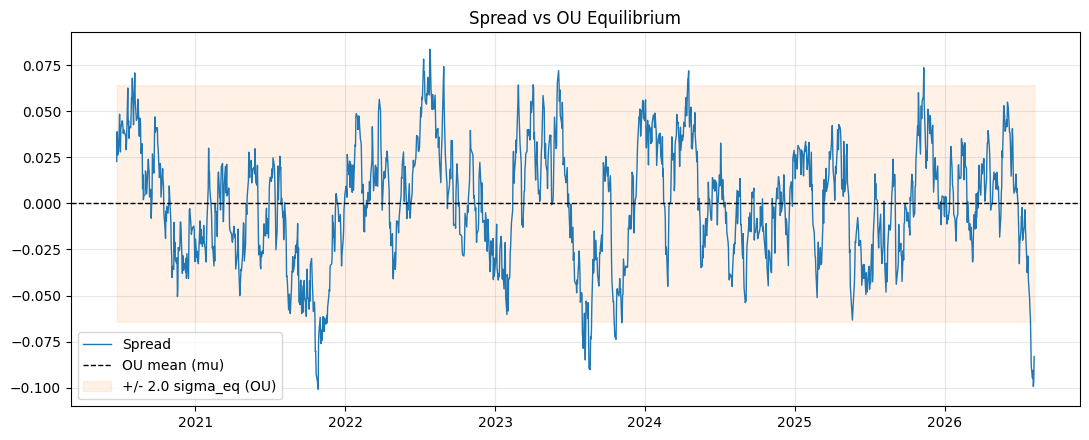

In [ ]:
z_ou = (result['spread'] - mu_hat) / sigma_eq

fig, ax = plt.subplots()
ax.plot(result['spread'].index, result['spread'], label='Spread', lw=1)
ax.axhline(mu_hat, color='black', ls='--', lw=1, label='OU mean (mu)')
ax.fill_between(result['spread'].index, mu_hat - CFG.z_entry * sigma_eq,
                 mu_hat + CFG.z_entry * sigma_eq, alpha=0.1, color='C1',
                 label=f'+/- {CFG.z_entry} sigma_eq (OU)')
ax.set_title('Spread vs OU Equilibrium')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Signal Generation (rolling z-score)

The backtest below uses a **rolling sample z-score** (re-estimated at each formation date,
using only past data) rather than the single full-sample OU fit above, which is shown mainly
for illustration since it was fit on the whole series. The walk-forward loop in Section 7
avoids that look-ahead problem.


In [ ]:
def generate_signals(log_a: pd.Series, log_b: pd.Series, gamma: float,
                      z_window: int, z_entry: float, z_exit: float):
    spread = log_a - gamma * log_b
    roll_mean = spread.rolling(z_window).mean()
    roll_std = spread.rolling(z_window).std()
    z = (spread - roll_mean) / roll_std

    position = 0   # 0 = flat, 1 = long spread, -1 = short spread
    positions = []
    for zt in z:
        if pd.isna(zt):
            positions.append(0)
            continue
        if position == 0:
            if zt < -z_entry:
                position = 1
            elif zt > z_entry:
                position = -1
        else:
            if abs(zt) < z_exit:
                position = 0
        positions.append(position)

    sig = pd.DataFrame({'spread': spread, 'z': z, 'position': positions}, index=log_a.index)
    return sig


## 6. Walk-Forward Backtest Engine

At each formation date, the hedge ratio and cointegration validity are estimated using
**only data available up to that point**. Trading then proceeds forward using that frozen
hedge ratio until the next reformation date. Risk controls (max holding period, stop-loss,
rolling cointegration re-check, hedge-ratio drift) are evaluated bar-by-bar using only
information available at that bar — no look-ahead.


In [ ]:
def run_backtest(prices: pd.DataFrame, cfg: Config):
    log_a = np.log(prices['A'])
    log_b = np.log(prices['B'])
    n = len(prices)

    trades = []
    equity = [cfg.capital_per_trade]
    equity_dates = [prices.index[0]]

    position = 0          # 0 flat, 1 long-spread, -1 short-spread
    entry_idx = None
    entry_gamma = None

    t = cfg.formation_window
    while t < n - 1:
        # --- FORMATION: estimate gamma + validate using only data up to t ---
        hist_a = log_a.iloc[t - cfg.formation_window: t]
        hist_b = log_b.iloc[t - cfg.formation_window: t]
        info = test_cointegration(hist_a, hist_b)
        hl = compute_half_life(info['spread'])

        pair_valid = (
            info['adf_pvalue'] < cfg.adf_pvalue_max
            and cfg.min_half_life <= hl <= cfg.max_half_life
        )
        gamma = info['gamma']

        # --- TRADE forward until next reformation date (or run out of data) ---
        window_end = min(t + cfg.reform_frequency, n - 1)

        for i in range(t, window_end):
            if i < cfg.z_window:
                continue

            hist_window_a = log_a.iloc[i - cfg.z_window: i + 1]
            hist_window_b = log_b.iloc[i - cfg.z_window: i + 1]
            spread_hist = hist_window_a - gamma * hist_window_b
            z = (spread_hist.iloc[-1] - spread_hist.mean()) / spread_hist.std()

            if position == 0:
                if not pair_valid:
                    continue
                if z < -cfg.z_entry:
                    position, entry_idx, entry_gamma = 1, i, gamma
                elif z > cfg.z_entry:
                    position, entry_idx, entry_gamma = -1, i, gamma
            else:
                exit_reason = None
                holding = i - entry_idx

                if abs(z) < cfg.z_exit:
                    exit_reason = 'target'
                elif holding >= cfg.max_holding_period:
                    exit_reason = 'max_holding_period'
                elif abs(z) > cfg.stop_loss_z:
                    exit_reason = 'stop_loss'
                else:
                    # rolling cointegration re-check on recent data only
                    recent_a = log_a.iloc[max(0, i - cfg.formation_window): i + 1]
                    recent_b = log_b.iloc[max(0, i - cfg.formation_window): i + 1]
                    if len(recent_a) >= 60 and i % 10 == 0:  # check periodically, not every bar (cost)
                        recent_info = test_cointegration(recent_a, recent_b)
                        if recent_info['adf_pvalue'] > cfg.retest_pvalue_max:
                            exit_reason = 'cointegration_broken'
                        elif abs(recent_info['gamma'] - entry_gamma) / abs(entry_gamma) > cfg.gamma_drift_limit:
                            exit_reason = 'gamma_drift'

                if exit_reason:
                    r_a = (prices['A'].iloc[i] - prices['A'].iloc[entry_idx]) / prices['A'].iloc[entry_idx]
                    r_b = (prices['B'].iloc[i] - prices['B'].iloc[entry_idx]) / prices['B'].iloc[entry_idx]
                    gross = (r_a - entry_gamma * r_b) if position == 1 else (-r_a + entry_gamma * r_b)
                    cost = 4 * cfg.cost_bps_per_leg / 10000.0   # 2 legs in + 2 legs out
                    net = gross - cost

                    trades.append({
                        'entry_date': prices.index[entry_idx], 'exit_date': prices.index[i],
                        'direction': 'long_spread' if position == 1 else 'short_spread',
                        'gamma': entry_gamma, 'holding_period': holding,
                        'gross_return': gross, 'net_return': net, 'exit_reason': exit_reason,
                    })
                    equity.append(equity[-1] * (1 + net))
                    equity_dates.append(prices.index[i])
                    position, entry_idx, entry_gamma = 0, None, None

        t += cfg.reform_frequency

    equity_curve = pd.Series(equity, index=equity_dates)
    trades_df = pd.DataFrame(trades)
    return trades_df, equity_curve


trades_df, equity_curve = run_backtest(prices, CFG)
print(f"Number of trades: {len(trades_df)}")
trades_df.head(10)


Number of trades: 24


,entry_date,exit_date,direction,gamma,holding_period,gross_return,net_return,exit_reason
0,2021-08-11,2021-08-26,long_spread,0.9404,11,0.0171,0.0167,target
1,2021-09-21,2021-09-30,long_spread,0.8086,7,0.0242,0.0238,target
2,2021-10-20,2021-10-26,long_spread,0.8086,4,-0.0174,-0.0178,gamma_drift
3,2021-10-27,2021-11-01,long_spread,0.8086,3,0.0383,0.0379,target
4,2021-12-01,2021-12-07,short_spread,0.8086,4,0.0134,0.0130,gamma_drift
5,2021-12-09,2021-12-21,short_spread,0.3114,8,0.0351,0.0347,target
6,2022-02-15,2022-03-01,long_spread,0.3114,10,0.0132,0.0128,gamma_drift
7,2022-12-20,2023-01-04,long_spread,0.6777,11,0.0189,0.0185,target
8,2023-01-30,2023-02-06,long_spread,0.6777,5,0.0201,0.0197,target
9,2023-02-13,2023-02-28,short_spread,0.6777,11,-0.0572,-0.0576,cointegration_broken


## 7. Performance Metrics

In [ ]:
def compute_performance(trades_df: pd.DataFrame, equity_curve: pd.Series, periods_per_year=252):
    if len(trades_df) == 0:
        print("No trades were generated - relax entry thresholds or check pair validity.")
        return {}

    total_return = equity_curve.iloc[-1] / equity_curve.iloc[0] - 1
    n_trades = len(trades_df)
    win_rate = (trades_df['net_return'] > 0).mean()
    avg_trade_return = trades_df['net_return'].mean()
    avg_holding = trades_df['holding_period'].mean()

    # approximate daily-equivalent returns from the (irregularly spaced) equity curve
    eq_returns = equity_curve.pct_change().dropna()
    avg_days_between = np.mean(np.diff(equity_curve.index).astype('timedelta64[D]').astype(float))
    periods_per_year_eff = 365.25 / avg_days_between if avg_days_between > 0 else periods_per_year

    sharpe = (eq_returns.mean() / eq_returns.std()) * np.sqrt(periods_per_year_eff) if eq_returns.std() > 0 else np.nan

    running_max = equity_curve.cummax()
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()

    exit_reason_counts = trades_df['exit_reason'].value_counts()

    metrics = {
        'Total Return': f"{total_return:.2%}",
        'Number of Trades': n_trades,
        'Win Rate': f"{win_rate:.2%}",
        'Average Trade Return': f"{avg_trade_return:.3%}",
        'Average Holding Period (bars)': f"{avg_holding:.1f}",
        'Sharpe Ratio (annualized, approx)': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_drawdown:.2%}",
    }

    print("=== Performance Summary ===")
    for k, v in metrics.items():
        print(f"{k:35s}: {v}")
    print("\n=== Exit Reasons ===")
    print(exit_reason_counts)

    return metrics


metrics = compute_performance(trades_df, equity_curve, CFG.periods_per_year)


=== Performance Summary ===
Total Return                       : 45.06%
Number of Trades                   : 24
Win Rate                           : 87.50%
Average Trade Return               : 1.589%
Average Holding Period (bars)      : 9.8
Sharpe Ratio (annualized, approx)  : 1.34
Max Drawdown                       : -5.76%

=== Exit Reasons ===
exit_reason
target                  20
gamma_drift              3
cointegration_broken     1
Name: count, dtype: int64


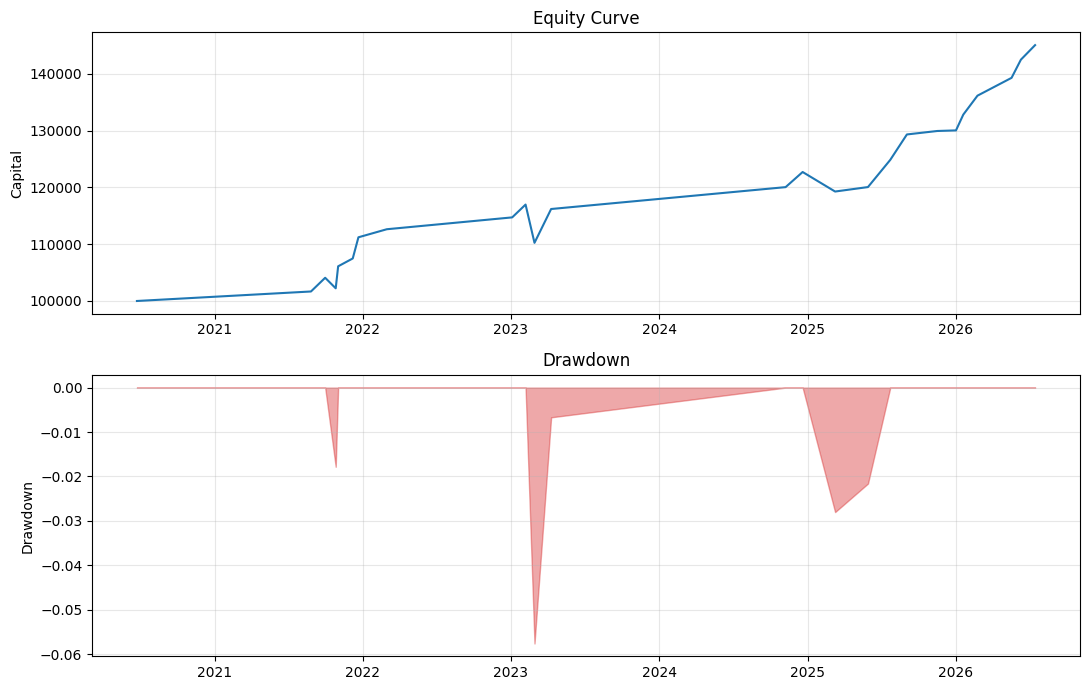

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

axes[0].plot(equity_curve.index, equity_curve.values)
axes[0].set_title('Equity Curve')
axes[0].set_ylabel('Capital')

running_max = equity_curve.cummax()
drawdown = (equity_curve - running_max) / running_max
axes[1].fill_between(drawdown.index, drawdown.values, 0, color='C3', alpha=0.4)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')

plt.tight_layout()
plt.show()


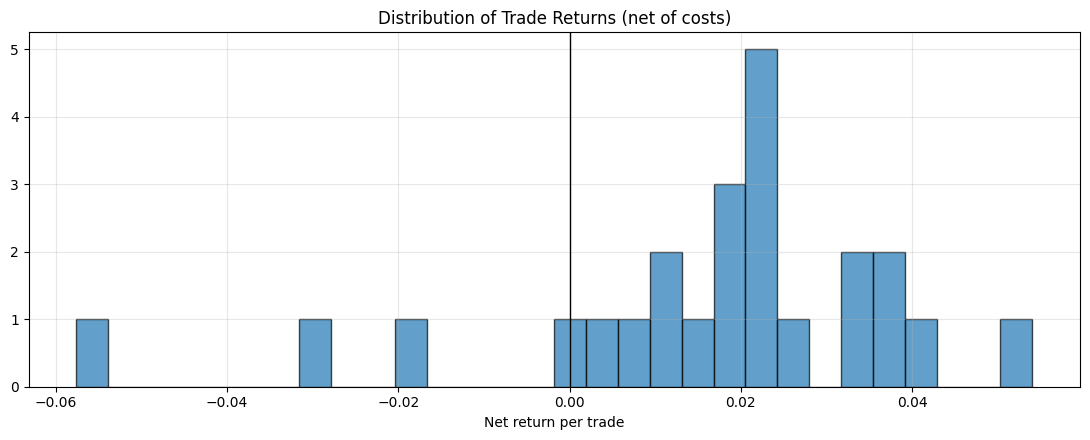

In [ ]:
if len(trades_df) > 0:
    fig, ax = plt.subplots()
    ax.hist(trades_df['net_return'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='black', lw=1)
    ax.set_title('Distribution of Trade Returns (net of costs)')
    ax.set_xlabel('Net return per trade')
    plt.tight_layout()
    plt.show()


## 8. Switching to Real FX Data

To run this on actual EUR/USD, GBP/USD, or other FX pairs on your own machine (this sandbox
has no network access to Yahoo Finance):

```python
CFG.data_source = "yfinance"
CFG.ticker_a = "EURUSD=X"
CFG.ticker_b = "GBPUSD=X"
CFG.start_date = "2015-01-01"
CFG.end_date = "2024-01-01"

prices = load_yfinance_pair(CFG.ticker_a, CFG.ticker_b, CFG.start_date, CFG.end_date)
```

Then re-run from Section 3 onward. Everything downstream (cointegration test, OU fit, signal
generation, backtest, metrics) is agnostic to the data source.

For FX specifically, also consider:
- Using **rate-differential-adjusted** spreads if holding periods are long enough for carry to matter.
- Checking session-time alignment (FX trades ~24h; make sure both series are sampled at the same times).
- Widening `max_half_life` / thresholds relative to equities, since major FX pairs can have
  longer, calmer mean-reversion cycles than single-name equities.


## 9. Limitations (read before using this on live capital)

- **Cointegration is not permanent.** A structural break (policy shift, central bank divergence,
  de-pegging, M&A) can permanently break the relationship. The rolling re-test and gamma-drift
  checks in the backtest are attempts to detect this *after the fact* — they do not predict it.
- **Estimation risk.** γ, μ, θ, σ, and half-life are all sample estimates with uncertainty,
  especially over shorter formation windows.
- **Multiple testing.** If this pipeline is run across many candidate pairs, some will pass the
  cointegration filter by chance. Out-of-sample validation on data untouched by parameter tuning
  is essential before trusting a backtest.
- **Transaction costs and slippage** used here (`cost_bps_per_leg`) are a simplification — real
  costs vary with liquidity, size, and market conditions, and short-leg borrow costs are not
  modeled at all.
- **This backtest still has simplifications relative to live trading**: fills are assumed at the
  bar's price with a flat cost, not at a realistic next-bar open with slippage; position sizing
  is notionally dollar-neutral rather than volatility-adjusted; and periodic (every-10-bar)
  rather than continuous cointegration re-checks are used to limit computation, which introduces
  a small amount of lag in detecting a broken relationship.
- **No result here is a guarantee of future performance**, on synthetic or real data.
